In [45]:
import tarfile
from tempfile import gettempdir
from urllib.request import urlretrieve
from pathlib import Path
from string import ascii_lowercase

import matplotlib.pyplot as plt
import tikzplotlib
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
from anndata import AnnData
from rpy2.robjects import r, pandas2ri

download data

In [2]:
tmp_path = Path(gettempdir()) / "dim-red"
tmp_path.mkdir(exist_ok=True)

if not (tar_path := tmp_path / "destiny.tar.gz").is_file():
    urlretrieve("http://bioconductor.org/packages/release/bioc/src/contrib/destiny_3.0.1.tar.gz", tar_path)

if not (rda_path := tmp_path / "guo_norm.rda").is_file():
    with tarfile.open(tar_path) as tf:
        reader = tf.extractfile("destiny/data/guo_norm.rda")
        rda_path.write_bytes(reader.read())

load data

In [3]:
pandas2ri.activate()

r["load"](str(rda_path))
adata = AnnData(
    r("t(guo_norm@assayData$exprs)"),
    r("guo_norm@phenoData@data"),
    dict(var_names=r("rownames(guo_norm@assayData$exprs)")),
)
#adata.obs["num_cells"] = pd.Categorical(adata.obs["num_cells"])

analyze

In [53]:
#sc.pp.log1p(adata)
sc.pp.neighbors(adata, 20)
sc.tl.pca(adata, )
sc.tl.diffmap(adata)
sc.tl.umap(adata)

plot

In [54]:
print(plt.style.available)

['tableau-colorblind10', 'dark_background', 'seaborn-paper', 'seaborn-colorblind', 'seaborn', 'fivethirtyeight', 'ggplot', 'seaborn-muted', 'seaborn-poster', 'Solarize_Light2', 'seaborn-darkgrid', 'grayscale', 'seaborn-ticks', 'seaborn-bright', 'seaborn-pastel', 'fast', 'classic', 'seaborn-white', 'seaborn-whitegrid', 'seaborn-dark-palette', 'seaborn-deep', '_classic_test', 'seaborn-dark', 'seaborn-talk', 'seaborn-notebook', 'bmh']


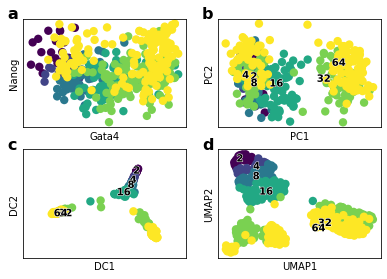

In [58]:
plt.style.use("seaborn-paper")
fig, axes = plt.subplots(2, 2)

kws = [
    dict(x="Gata4", y="Nanog"),
    dict(basis="pca"),
    dict(basis="diffmap"),
    dict(basis="umap"),
]
for letter, kw, ax in zip(ascii_lowercase, kws, axes.flatten()):
    scv.pl.scatter(adata, **kw, color='num_cells', palette='viridis', frameon=True, title="", ax=ax, show=False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(-0.1, 1, letter, transform=ax.transAxes, size=16, weight='bold')

#plt.xlabel("time (s)")
#plt.ylabel("Voltage (mV)")
#plt.title("Simple plot $\\frac{\\alpha}{2}$")
#plt.grid(True)
 
#tikzplotlib.save("dim-red.tikz", flavor="context")
plt.savefig("dim-red.pdf")